# Weighting Timesteps | NeuralForecast
> Assign relative importance weights to individual timesteps when training a model.

## Motivation

When working with time series data, it is possible that we want to assign a higher or lower importance to certain values or periods in the series.

For example, historical sales data cover the abnormal COVID period, so the model should not learn too much from that historical sequence. Alternativaly, you might be interested in the model being very good at modeling periods when a promotion is running. 

Thus, we need to a way to tell the model when to assign more or less importance to specific timesteps.

## Understanding `sample_weight`

The `sample_weight` is a reserved column name, similar to how we expect the data to have columns `["unique_id", "ds", "y"]`. In that column, we can assign a positive integer to indicate how important a timestep is. 

- Assigning a value of 0 means the particular timestep does not contribute to the loss.
- Higher values increase the contribution to the loss, so the model learns "more" about these timesteps.

### Key considerations
Deep learning models are trained with windows of data. Internally, we take the mean of the `sample_weight` for a window to get its relative importance. Therefore, training windows are never completely ignored, unless the entire window has timesteps with `sample_weight` of 0. 

In most cases, windows with timesteps assigned to a `sample_weight` of 0 will have a lower "mean importance", and so will contribute less to the loss of the model. 

Take the following example:                                                                                                         
                                                                                                                                      
| ds | y | sample_weight |                                                                                                    
|---|---|---|                                                                                                                       
| t1 | ... | 1 |                                                                                                                    
| t2 | ... | 1 |                                                                                                                    
| t3 | ... | 1 |                                                                                                                    
| t4 | ... | 1 |
| t5 | ... | 0 |                                                                                                                    
| t6 | ... | 0 |
| t7 | ... | 0 |                                                                                                                    
| t8 | ... | 0 |           
| t9 | ... | 1 |
| t10 | ... | 1 |                                                                                                                   
| t11 | ... | 1 |
| t12 | ... | 1 |                                                                                                                   
                            
With `input_size=4` and `h=4`, NeuralForecast creates sliding windows of 8 timesteps. The `sample_weight` for each window is the    
mean over its **forecast horizon** (the future portion):
                                                                                                                                    
| Window | Input (t) | Future (t) | Mean `sample_weight` |
|---|---|---|---|
| 1 | t1 – t4 | t5 – t8 | **0.00** — ignored |
| 2 | t2 – t5 | t6 – t9 | 0.25 — low importance |                                                                                   
| 3 | t3 – t6 | t7 – t10 | 0.50 — moderate importance |
| 4 | t4 – t7 | t8 – t11 | 0.75 — high importance |                                                                                 
| 5 | t5 – t8 | t9 – t12 | **1.00** — full importance |
                                                                                                                                    
Window 1 is completely excluded from training: its entire forecast horizon falls within the zeroed period. Windows 2–4 contribute progressively more as the horizon moves out of it. Window 5 trains normally. The model still "sees" timesteps in the input context of windows 2–5. It learns what happened during that period, without being penalized for predicting its future.

### Important notes
- `sample_weight` must be greater than or equal to 0
- there is no upper bound for `sample_weight`. It works as a relative importance. So a value of 2 vs 1 means "twice as important". 100 vs 50 would be interpreted the same way.

## Usage

Let's see an example of how `sample_weight` can be used in practice. We use the Air Passengers dataset and cover different scenarios.

### Setup

In [ ]:
import logging
import warnings

import numpy as np

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae
from utilsforecast.plotting import plot_series

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

### Load data

In [4]:
from neuralforecast.utils import AirPassengersDF

Y_df = AirPassengersDF.copy()
Y_train_df = Y_df[Y_df.ds <= "1959-12-31"]  # 132 months train
Y_test_df = Y_df[Y_df.ds > "1959-12-31"]    # 12 months test

Y_train_df.tail()

,unique_id,ds,y
127,1.0,1959-08-31,559.0
128,1.0,1959-09-30,463.0
129,1.0,1959-10-31,407.0
130,1.0,1959-11-30,362.0
131,1.0,1959-12-31,405.0


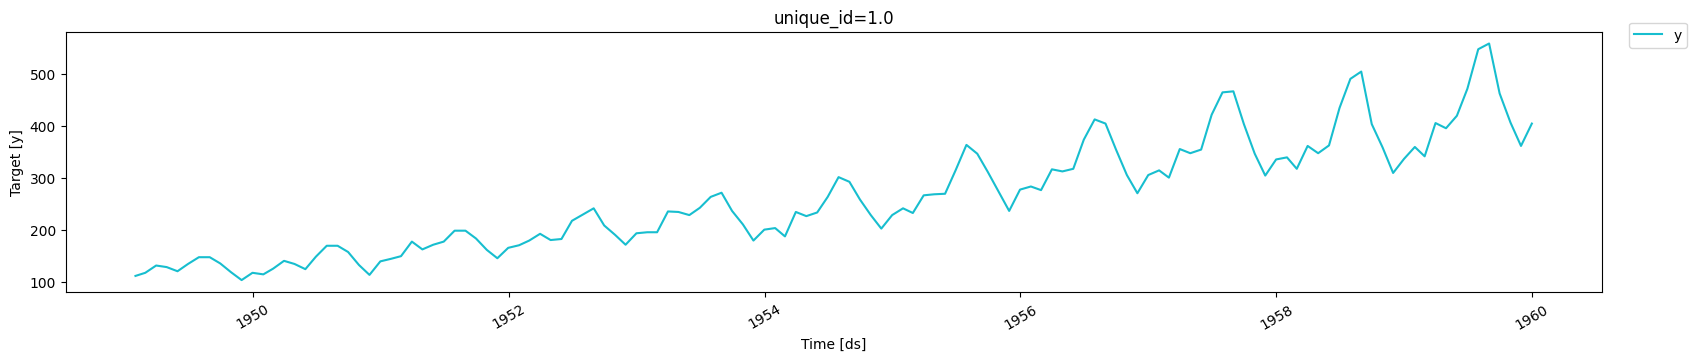

In [6]:
plot_series(Y_train_df)

### Prolonged anomaly

Here, we inject a prolonged anomaly where values are 50% lower than they actually are. For that anomalous period, we set `sample_weight` to 0, and 1 otherwise. We then compare how the model performs when setting `sample_weight` against using the default behavior.

In [7]:
s1 = Y_train_df.copy()                                                                                                              
anomaly_mask = s1["ds"].between("1953-01-31", "1953-12-31")                                                                         
s1.loc[anomaly_mask, "y"] *= 0.5                                                                                                    
s1["sample_weight"] = 1.0  
s1.loc[anomaly_mask, "sample_weight"] = 0.0 

s1.head()

,unique_id,ds,y,sample_weight
0,1.0,1949-01-31,112.0,1.0
1,1.0,1949-02-28,118.0,1.0
2,1.0,1949-03-31,132.0,1.0
3,1.0,1949-04-30,129.0,1.0
4,1.0,1949-05-31,121.0,1.0


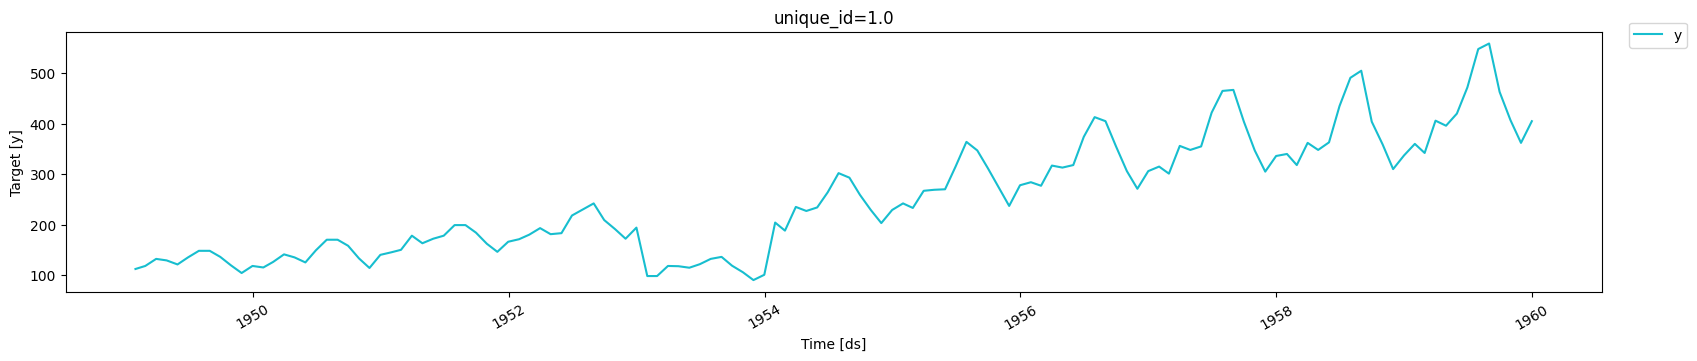

In [8]:
plot_series(s1)

#### Training and evaluating

In [15]:
H = 12
MAX_STEPS = 100

models = [
    NHITS(
        h=H, 
        input_size=3*H, 
        max_steps=MAX_STEPS, 
        scaler_type="robust", 
        enable_progress_bar=False, 
        enable_model_summary=False
    )
]

nf = NeuralForecast(models=models, freq="ME")

# With `sample_weight`
nf.fit(df=s1)
preds_sw = nf.predict()
preds_sw = preds_sw.rename(columns={"NHITS": "NHITS_SW"})

# Without `sample_weight`
nf.fit(df=s1.drop(columns=["sample_weight"]))
preds = nf.predict()

eval_df = Y_test_df.merge(preds_sw, "left", ["unique_id", "ds"])
eval_df = eval_df.merge(preds, "left", ["unique_id", "ds"])

evaluation = evaluate(eval_df, metrics=[mae])
evaluation

Seed set to 1


,unique_id,metric,NHITS_SW,NHITS
0,1.0,mae,18.040064,45.309769


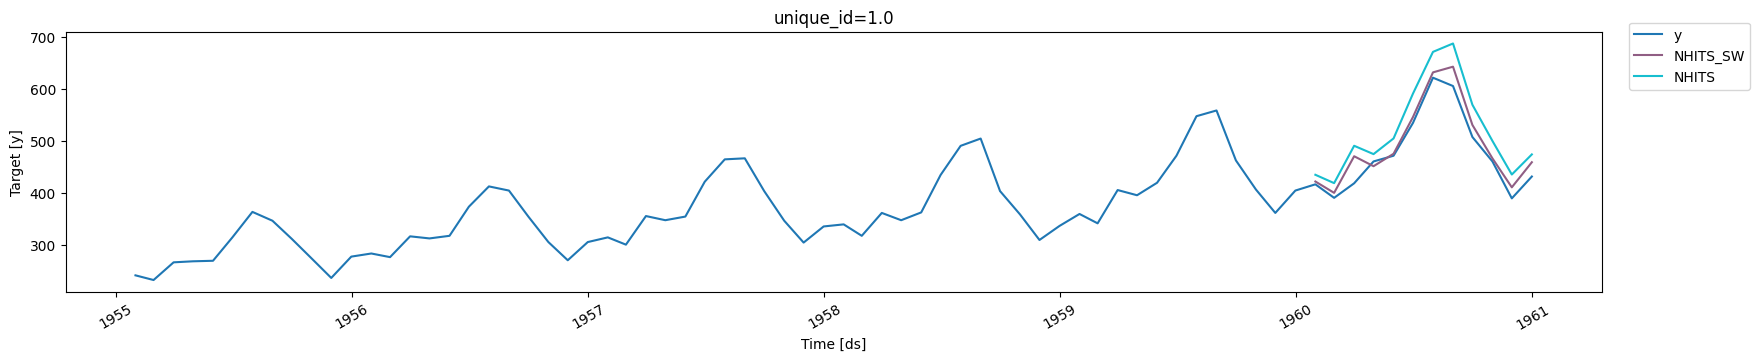

In [22]:
plot_series(s1, eval_df, max_insample_length=5*12)

From the figure above and from the calculated MAE, we can see that using `sample_weight` improved the performance of the model as we assigned less importance to the anomalous period.

### Isolated anomalies

Now, let's consider a scenario where isolated anomalies occur in the data. As before, we assign a `sample_weight` of 0 to those anomalies and 1 otherwise, and compare the performance.

In [30]:
rng = np.random.default_rng(42)                                                                                                     
s2 = Y_train_df.copy()                                                                                                              
outlier_idx = rng.choice(s2.index, size=4, replace=False)                                                                           
s2.loc[outlier_idx, "y"] *= rng.uniform(2.0, 3.0, size=4)  # random spikes
s2["sample_weight"] = 1.0                                                                                                           
s2.loc[outlier_idx, "sample_weight"] = 0.0

In [38]:
s2.head()

,unique_id,ds,y,sample_weight
0,1.0,1949-01-31,112.0,1.0
1,1.0,1949-02-28,118.0,1.0
2,1.0,1949-03-31,132.0,1.0
3,1.0,1949-04-30,129.0,1.0
4,1.0,1949-05-31,121.0,1.0


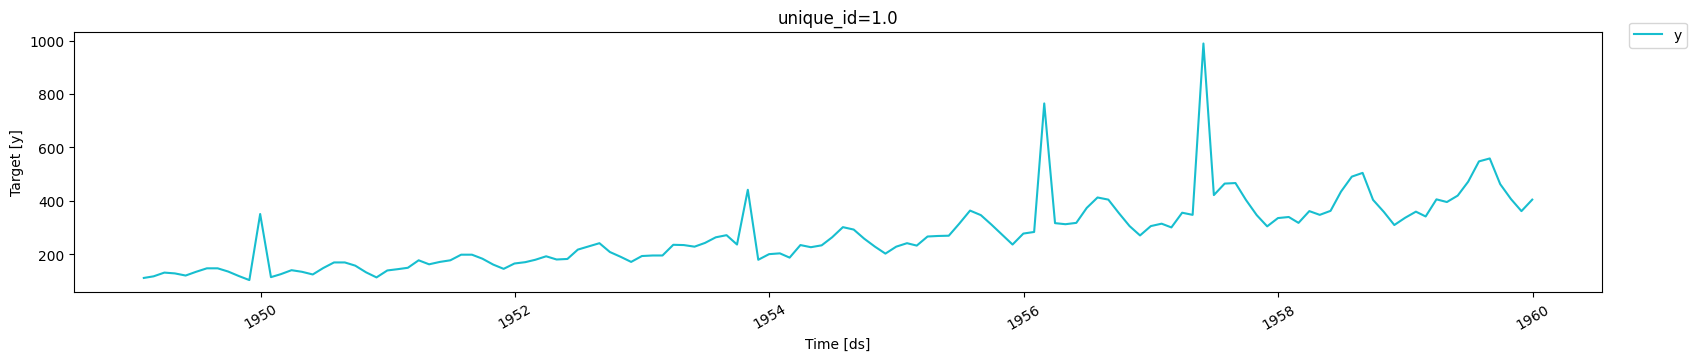

In [31]:
plot_series(s2)

#### Training and evaluating

In [32]:
# With `sample_weight`
nf.fit(df=s2)
preds_sw = nf.predict()
preds_sw = preds_sw.rename(columns={"NHITS": "NHITS_SW"})

# Without `sample_weight`
nf.fit(df=s2.drop(columns=["sample_weight"]))
preds = nf.predict()

eval_df = Y_test_df.merge(preds_sw, "left", ["unique_id", "ds"])
eval_df = eval_df.merge(preds, "left", ["unique_id", "ds"])

evaluation = evaluate(eval_df, metrics=[mae])
evaluation

,unique_id,metric,NHITS_SW,NHITS
0,1.0,mae,62.247646,61.333698


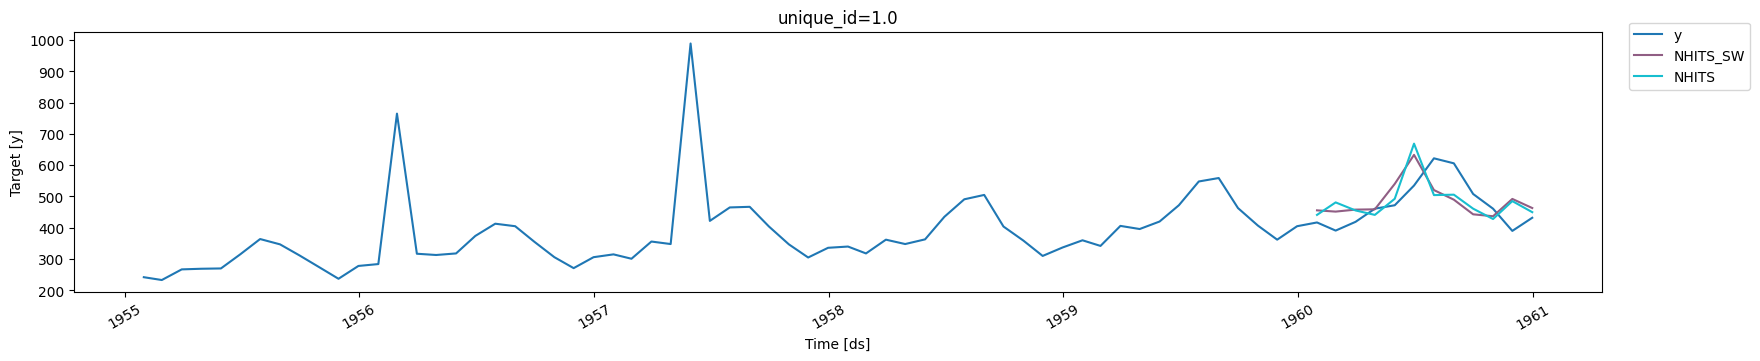

In [33]:
plot_series(s2, eval_df, max_insample_length=5*12)

In this case, using the `sample_weight` is not sufficient. In fact, the model performs slightly worse than not using `sample_weight`. Here, it might be beneficial to use other methods robust to outliers, like selecting the `HuberLoss` as the optimization objective.

### Emphasize certain periods

Now, let's consider the scenario where we want to give more importance to the summer months. Those are the months with the highest traffic, so we might want our model to be espcially good in those periods.

In [35]:
s3 = Y_train_df.copy()
s3["sample_weight"] = 1.0                                                                                                           
summer_mask = s3["ds"].dt.month.isin([6, 7, 8])
s3.loc[summer_mask, "sample_weight"] = 3.0  

In [40]:
s3.tail()

,unique_id,ds,y,sample_weight
127,1.0,1959-08-31,559.0,3.0
128,1.0,1959-09-30,463.0,1.0
129,1.0,1959-10-31,407.0,1.0
130,1.0,1959-11-30,362.0,1.0
131,1.0,1959-12-31,405.0,1.0


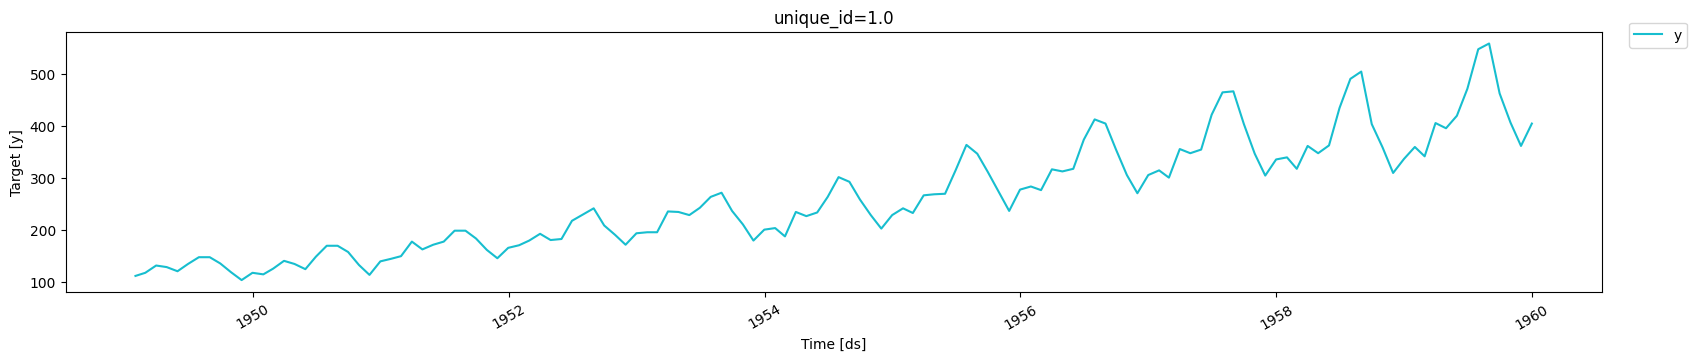

In [36]:
plot_series(s3)

#### Training and evaluating

In [41]:
# With `sample_weight`
nf.fit(df=s3)
preds_sw = nf.predict()
preds_sw = preds_sw.rename(columns={"NHITS": "NHITS_SW"})

# Without `sample_weight`
nf.fit(df=s3.drop(columns=["sample_weight"]))
preds = nf.predict()

eval_df = Y_test_df.merge(preds_sw, "left", ["unique_id", "ds"])
eval_df = eval_df.merge(preds, "left", ["unique_id", "ds"])

evaluation = evaluate(eval_df, metrics=[mae])
evaluation

,unique_id,metric,NHITS_SW,NHITS
0,1.0,mae,11.672673,13.421109


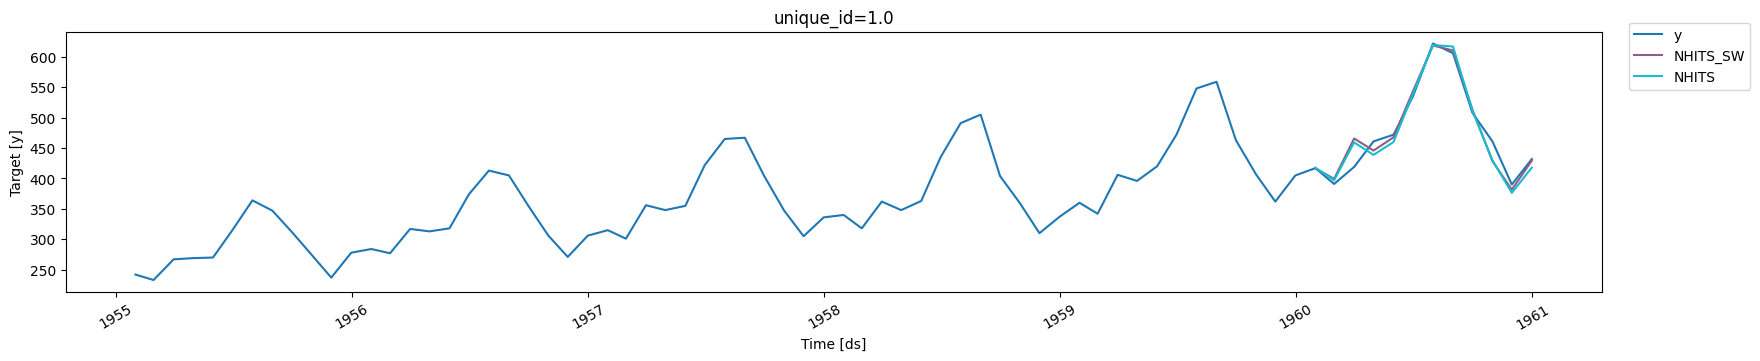

In [42]:
plot_series(s3, eval_df, max_insample_length=5*12)

Here, we see that using `sample_weight` improved the performance again. Although it's hard to see in the plot, the model trained with `sample_weight` better forecasts the peaks of summer, resulting in a performance gain.

## Summary

NeuralForecast now supports the `sample_weight` column which is a reserved column name to indicate the relative importance of each timestep. 

During training, the `sample_weight` of each window is the mean over the forecast horizon. This helps the model either ignore anomalous sequences or data points, or focus more on important periods.